In [2]:
# Phase 1: Data Ingestion and Green Flag Cleaning
import fastf1
import pandas as pd
import os

print("Entering the strategy room... Extracting Race Telemetry!\n")

cache_dir = 'f1_cache'
if not os.path.exists(cache_dir):
    os.makedirs(cache_dir)
fastf1.Cache.enable_cache(cache_dir)

year = 2023
grand_prix = 'Bahrain'
print(f"Loading {year} {grand_prix} Grand Prix...")
session = fastf1.get_session(year, grand_prix, 'R')
session.load(telemetry=False, weather=True, messages=False)

laps = session.laps

print("Filtering out Safety Cars, VSCs, and Pit Stops...")

clean_laps = laps.pick_track_status('1')

clean_laps = clean_laps.pick_quicklaps()

clean_laps = clean_laps.dropna(subset=['LapTime', 'TyreLife', 'Compound', 'LapNumber']).reset_index(drop=True)

#====================
# Feature Extraction
#====================
# Convert lap time timedelta to raw float seconds
clean_laps['LapTime_Sec'] = clean_laps['LapTime'].dt.total_seconds()

# We need the track temperature to see if hotter tracks slow the cars down
# We extract this from the weather data attached to each lap
weather_data = clean_laps.get_weather_data()
clean_laps['TrackTemp'] = weather_data['TrackTemp'].values

features_to_keep = [
    'Driver',
    'LapNumber',
    'Compound', # Soft, Medium, Hard
    'TyreLife',
    'TrackTemp',
    'LapTime_Sec'
]

ml_df = clean_laps[features_to_keep].copy()

print("\n Clean Race Data Extracted!")
print("-"*80)
print(ml_df.head(10))


core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count


Entering the strategy room... Extracting Race Telemetry!

Loading 2023 Bahrain Grand Prix...


req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for weather_data
core           INFO 	Finished loading data for 20 drivers: ['1', '11', '14', '55', '44', '18', '63', '77', '10', '23', '22', '2', '20', '21', '27', '24', '4', '31', '16', '81']


Filtering out Safety Cars, VSCs, and Pit Stops...

 Clean Race Data Extracted!
--------------------------------------------------------------------------------
  Driver  LapNumber Compound  TyreLife  TrackTemp  LapTime_Sec
0    VER        3.0     SOFT       6.0       31.2       98.006
1    VER        4.0     SOFT       7.0       31.2       97.976
2    VER        5.0     SOFT       8.0       31.0       98.035
3    VER        6.0     SOFT       9.0       31.0       97.986
4    VER        7.0     SOFT      10.0       30.9       98.021
5    VER        8.0     SOFT      11.0       30.9       98.154
6    VER        9.0     SOFT      12.0       30.9       98.278
7    VER       10.0     SOFT      13.0       30.8       98.369
8    VER       11.0     SOFT      14.0       30.6       98.483
9    VER       12.0     SOFT      15.0       30.6       98.591


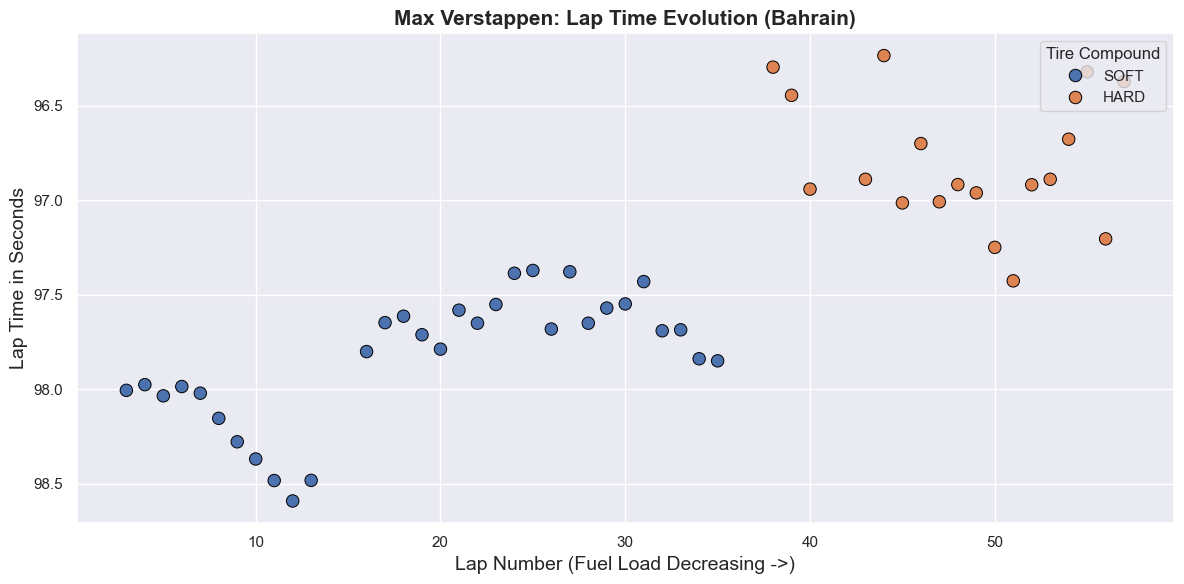


 Data is fully numeric and ready for modeling. Final dataset structure:
<class 'fastf1.core.Laps'>
RangeIndex: 802 entries, 0 to 801
Data columns (total 24 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   LapNumber        802 non-null    float64
 1   TyreLife         802 non-null    float64
 2   TrackTemp        802 non-null    float64
 3   LapTime_Sec      802 non-null    float64
 4   Compound_MEDIUM  802 non-null    bool   
 5   Compound_SOFT    802 non-null    bool   
 6   Driver_ALO       802 non-null    bool   
 7   Driver_BOT       802 non-null    bool   
 8   Driver_DEV       802 non-null    bool   
 9   Driver_GAS       802 non-null    bool   
 10  Driver_HAM       802 non-null    bool   
 11  Driver_HUL       802 non-null    bool   
 12  Driver_LEC       802 non-null    bool   
 13  Driver_MAG       802 non-null    bool   
 14  Driver_NOR       802 non-null    bool   
 15  Driver_OCO       802 non-null    bool   
 16  

In [3]:
# Phase 2: EDA and Preprocessing
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 2.1 Visualization Real Tire Degradation
sns.set_theme(style="darkgrid")

# Let's isolate Max Verstappen (VER) to see a clean, race-winning stint
ver_laps = ml_df[ml_df['Driver'] == 'VER']

plt.figure(figsize=(12, 6))
sns.scatterplot(data=ver_laps, x='LapNumber', y='LapTime_Sec', hue='Compound', s=80, edgecolor='black')

plt.title('Max Verstappen: Lap Time Evolution (Bahrain)', fontsize=15, fontweight='bold')
plt.xlabel('Lap Number (Fuel Load Decreasing ->)', fontsize=14)
plt.ylabel('Lap Time in Seconds', fontsize=14)

plt.gca().invert_yaxis()
plt.legend(title='Tire Compound', loc='upper right')
plt.tight_layout()
plt.show()

# 2.2 Categorical Encoding

ml_df_encoded = pd.get_dummies(ml_df, columns=['Compound', 'Driver'], drop_first=True)

print("\n Data is fully numeric and ready for modeling. Final dataset structure:")
print(ml_df_encoded.info())

Training on 641 laps, Testing on 161 laps...

XGBoost Model Successfully Trained!

Model Performance Metrics
--------------------------------------------------------------------------------
Mean Absolute Error: 0.334 seconds
Root Mean Squared Error: 0.602 seconds



<Figure size 1000x800 with 0 Axes>

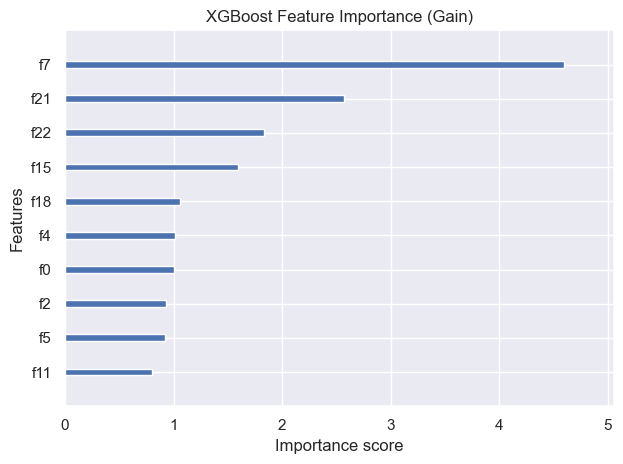

In [4]:
# Phase 3: XGBoost Training and Feature Importance
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

X = ml_df_encoded.drop(columns=['LapTime_Sec'])
y = ml_df_encoded['LapTime_Sec']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training on {len(X_train)} laps, Testing on {len(X_test)} laps...\n")

xgb_model = xgb.XGBRegressor(
n_estimators = 150,
    learning_rate = 0.1,
    max_depth = 5,
    random_state = 42,
    n_jobs = -1
)

xgb_model.fit(X_train, y_train)
print("XGBoost Model Successfully Trained!\n")

y_pred = xgb_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Model Performance Metrics")
print("-"*80)
print(f"Mean Absolute Error: {mae:.3f} seconds")
print(f"Root Mean Squared Error: {rmse:.3f} seconds\n")

plt.figure(figsize=(10, 8))
xgb.plot_importance(xgb_model, max_num_features=10, importance_type='gain', show_values=False, title='XGBoost Feature Importance (Gain)')
plt.tight_layout()
plt.show()

In [5]:
import pandas as pd
import numpy as np

print("Deploying Live Race Strategy Tool...\n")

def format_stopwatch(raw_seconds):
    minutes = int(raw_seconds // 60)
    seconds = raw_seconds % 60
    return f"{minutes}:{seconds:06.3f}"

def predict_race_pace(driver, lap_number, compound, tyre_life, track_temp, model, feature_columns):
    input_data = pd.DataFrame(np.zeros((1, len(feature_columns))), columns=feature_columns)
    input_data['LapNumber'] = lap_number
    input_data['TyreLife'] = tyre_life
    input_data['TrackTemp'] = track_temp

    compound_col = f'Compound_{compound.upper()}'
    if compound_col in input_data.columns:
        input_data[compound_col] = 1
    
    driver_col = f'Driver_{driver.upper()}'
    if driver_col in input_data.columns:
        input_data[driver_col] = 1
    else:
        print(f"Warning: Driver '{driver} not found in training data.")
    
    predicted_seconds = model.predict(input_data)[0]

    formatted_time = format_stopwatch(predicted_seconds)

    print(f"🏎️{driver}🏎️")
    print(f"Conditions: Lap{lap_number} | {compound} Tires (Age: {tyre_life} laps) | Track: {track_temp}℃")
    print("-"*80)
    print(f"Expected Lap Time: {formatted_time} ({predicted_seconds:.3f}s)\n")

    return predicted_seconds



Deploying Live Race Strategy Tool...



Generating Performance Analysis...



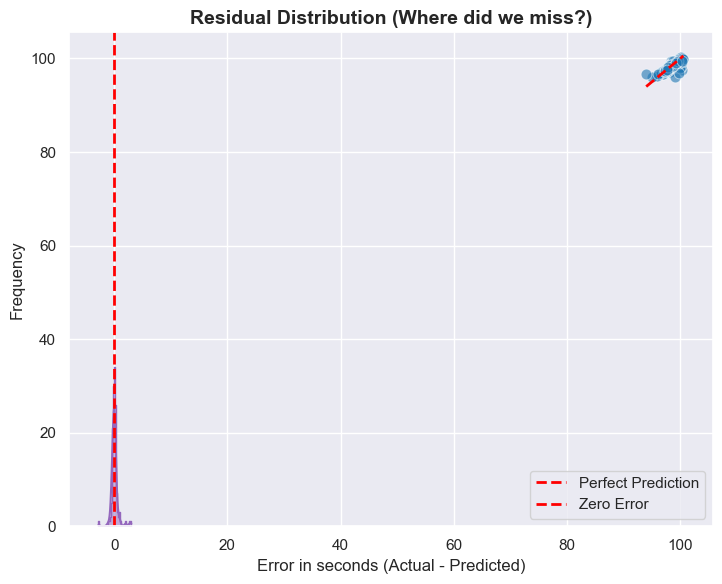

Error Analysis Summary:
Largest Over-prediction (Predicted too slow): -2.764s
largest Under-predition (Predicted too fast): 3.038s


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Generating Performance Analysis...\n")

residuals = y_test - y_pred

plt.figure(figsize=(14,6))

# Actual vs Predicted Scatter plot

plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, color='#1f77b4', edgecolor='w', s=60)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle="--", linewidth=2, label='Perfect Prediction')

plt.title('Actual vs Predicted Lap Time', fontsize=14, fontweight='bold')
plt.xlabel('Actual Lap Time (seconds)', fontsize=12)
plt.ylabel('Predicted Lap Time (seconds)', fontsize=12)
plt.legend()

# Residual (Error) Distribution

plt.subplot(1, 2, 1)
sns.histplot(residuals, kde=True, color='#9467bd', bins=40, element='step')

plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
plt.title('Residual Distribution (Where did we miss?)', fontsize=14, fontweight='bold')
plt.xlabel('Error in seconds (Actual - Predicted)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()

plt.tight_layout()
plt.show()

print("Error Analysis Summary:")
print(f"Largest Over-prediction (Predicted too slow): {residuals.min():.3f}s")
print(f"largest Under-predition (Predicted too fast): {residuals.max():.3f}s")

In [10]:
import joblib

print("Exporting model and features...\n")

joblib.dump(xgb_model, 'xgb_lap_time_model.pkl')

joblib.dump(list(X_train.columns), 'model_feature_columns.pkl')

print("Model successfully saved as 'xgb_lap_time_model.pkl'!")
print("Features successfully saved as 'model_feature_columns.pkl'!")

Exporting model and features...

Model successfully saved as 'xgb_lap_time_model.pkl'!
Features successfully saved as 'model_feature_columns.pkl'!
